# Stage 6: Feature Importance (MDI, MDA, SFI)

AFML Ch 8. Compute three complementary importance measures, identify consistently uninformative features (bottom 25 % across all three rankings), drop them, and refit the final RF on the reduced feature set.

In [1]:
import sys, os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

sys.path.append('../')
from src.cross_validation import PurgedKFold
from src.feature_importance import (
    feat_imp_MDI, feat_imp_MDA, feat_imp_SFI, plot_feature_importance,
)

plt.style.use('seaborn-v0_8-darkgrid')
RNG = 42
os.makedirs('../reports/figures', exist_ok=True)


## 1. Load modelling dataset and tuned hyperparameters

In [2]:
dataset = pd.read_parquet('../data/processed/nvda_modelling_dataset.parquet')
X = dataset.drop(columns=['label', 'weight', 't1'])
y = dataset['label'].astype(int)
sample_weight = dataset['weight']
t1 = dataset['t1']

with open('../models/best_params.json') as f:
    best = json.load(f)
rf_params = best['rf']['params']
print('Tuned RF params:', rf_params)

pkf = PurgedKFold(n_splits=5, t1=t1, pct_embargo=0.01)

Tuned RF params: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 7, 'class_weight': 'balanced_subsample'}


## 2. Fit RF with tuned hyperparameters on full data

In [3]:
rf = RandomForestClassifier(
    **rf_params, random_state=RNG, n_jobs=-1,
)
rf.fit(X, y, sample_weight=sample_weight.values)
rf

,n_estimators,200
,criterion,'gini'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 3. MDI — Mean Decrease in Impurity

In [4]:
mdi = feat_imp_MDI(rf, X.columns)
mdi.round(4)

,mean,std
fracdiff,0.0936,0.0070
vol_50d,0.0756,0.0067
log_dollar_volume,0.0755,0.0066
amihud_illiquidity,0.0721,0.0060
volume_ratio,0.0671,0.0059
bekker_parkinson_vol,0.0669,0.0058
ret_10d,0.0616,0.0059
roll_spread,0.0597,0.0054
vol_20d,0.0592,0.0057
ret_20d,0.0591,0.0049


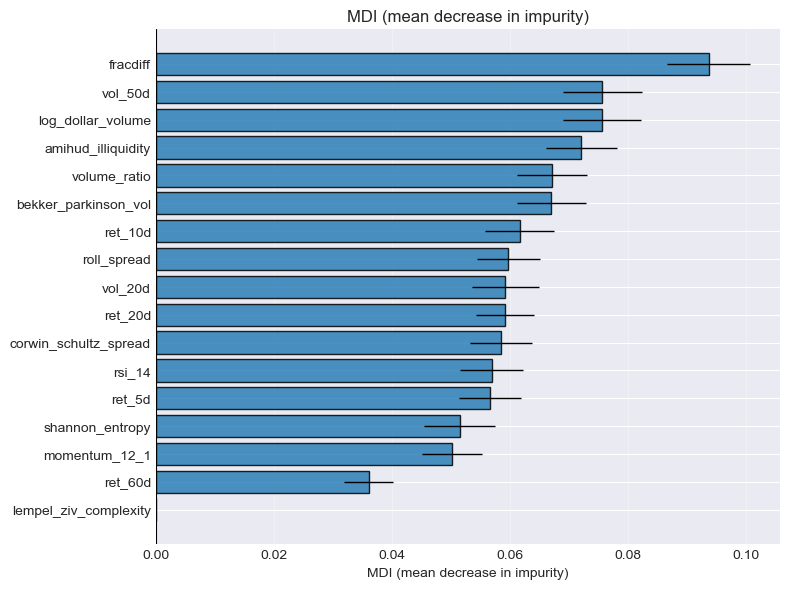

In [5]:
fig = plot_feature_importance(mdi, 'MDI (mean decrease in impurity)',
                              color='#2c7fb8')
fig.savefig('../reports/figures/P15_mdi_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. MDA — Mean Decrease in Accuracy (log-loss permutation)

Per AFML, log-loss is the score for MDA on small classification samples — it responds smoothly to the predicted-probability shifts caused by permuting one column.

In [6]:
mda = feat_imp_MDA(
    clf=rf, X=X, y=y, cv=pkf,
    sample_weight=sample_weight, scoring='neg_log_loss',
    random_state=RNG,
)
mda.round(4)

,mean,std
fracdiff,0.0129,0.0082
vol_50d,0.0044,0.0029
amihud_illiquidity,0.0028,0.0014
ret_5d,0.0028,0.0031
shannon_entropy,0.0022,0.0026
corwin_schultz_spread,0.0007,0.0033
roll_spread,0.0006,0.0027
bekker_parkinson_vol,0.0006,0.0039
lempel_ziv_complexity,0.0000,0.0000
momentum_12_1,-0.0003,0.0043


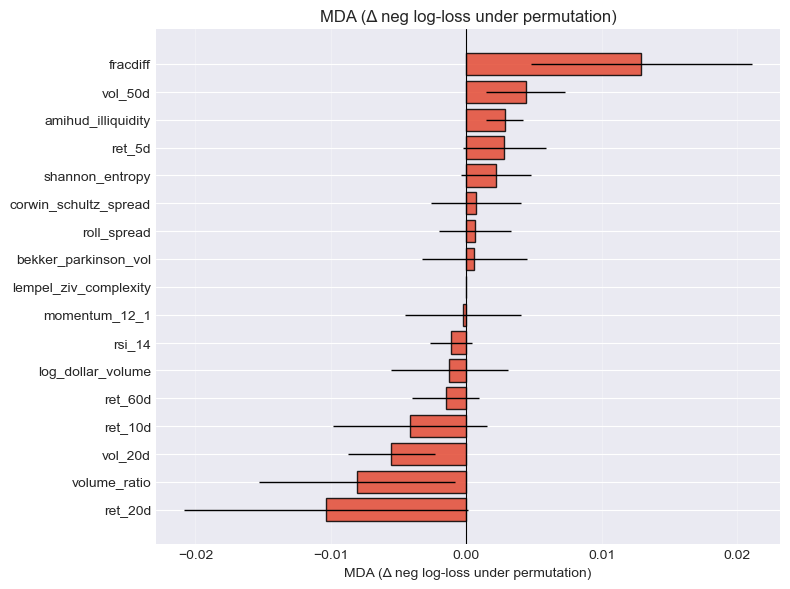

In [7]:
fig = plot_feature_importance(mda, 'MDA (Δ neg log-loss under permutation)',
                              color='#e34a33')
fig.savefig('../reports/figures/P16_mda_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. SFI — Single Feature Importance

In [8]:
sfi_template = RandomForestClassifier(
    **rf_params, random_state=RNG, n_jobs=-1,
)
sfi = feat_imp_SFI(
    clf_template=sfi_template, X=X, y=y, cv=pkf,
    sample_weight=sample_weight, scoring='neg_log_loss',
)
sfi.round(4)

,mean,std
lempel_ziv_complexity,-0.6907,0.0045
bekker_parkinson_vol,-0.7425,0.0430
ret_60d,-0.7537,0.0250
corwin_schultz_spread,-0.7542,0.0217
ret_5d,-0.7554,0.0180
roll_spread,-0.7619,0.0357
momentum_12_1,-0.7794,0.0361
vol_20d,-0.7885,0.0356
fracdiff,-0.8142,0.0555
rsi_14,-0.8170,0.0348


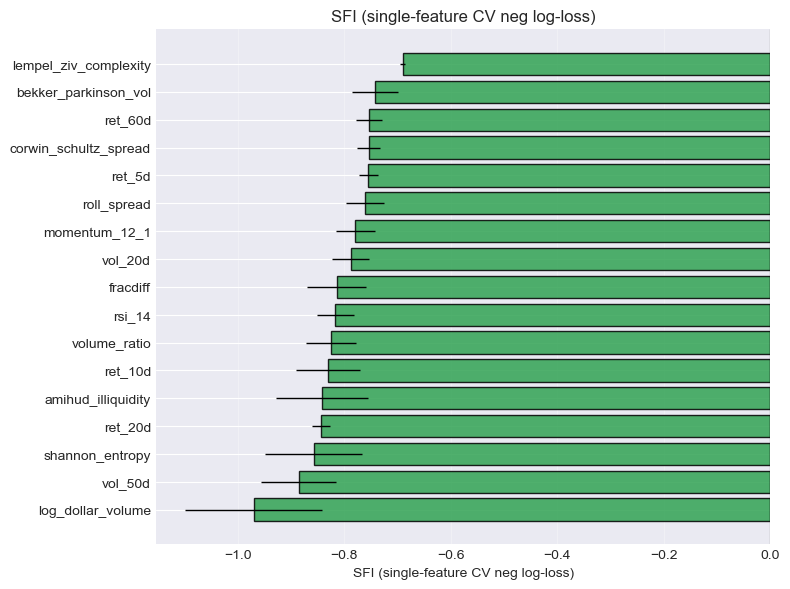

In [9]:
fig = plot_feature_importance(sfi, 'SFI (single-feature CV neg log-loss)',
                              color='#31a354')
fig.savefig('../reports/figures/P17_sfi_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Rank comparison and correlation

In [10]:
rank_df = pd.DataFrame({
    'MDI_rank': mdi['mean'].rank(ascending=False).astype(int),
    'MDA_rank': mda['mean'].rank(ascending=False).astype(int),
    'SFI_rank': sfi['mean'].rank(ascending=False).astype(int),
}).reindex(X.columns)
rank_df['avg_rank'] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values('avg_rank')
rank_df

,MDI_rank,MDA_rank,SFI_rank,avg_rank
fracdiff,1,1,9,3.666667
bekker_parkinson_vol,6,8,2,5.333333
amihud_illiquidity,4,3,13,6.666667
vol_50d,2,2,16,6.666667
corwin_schultz_spread,11,6,4,7.000000
roll_spread,8,7,6,7.000000
ret_5d,13,4,5,7.333333
lempel_ziv_complexity,17,9,1,9.000000
ret_60d,16,13,3,10.666667
volume_ratio,5,16,11,10.666667


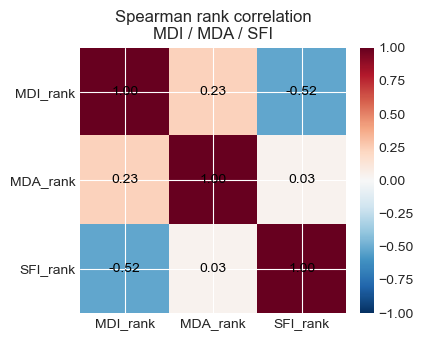

In [11]:
rank_corr = rank_df[['MDI_rank', 'MDA_rank', 'SFI_rank']].corr(method='spearman')

fig, ax = plt.subplots(figsize=(4.5, 3.5))
im = ax.imshow(rank_corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(rank_corr.columns)
ax.set_yticklabels(rank_corr.index)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{rank_corr.values[i, j]:.2f}',
                ha='center', va='center', color='black', fontsize=10)
ax.set_title('Spearman rank correlation\nMDI / MDA / SFI')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 7. Identify uninformative features

Drop features that fall in the **bottom 25 %** of all three rankings.

In [12]:
n_features = len(X.columns)
bottom_n = max(1, int(np.ceil(n_features * 0.25)))
bottom_threshold = n_features - bottom_n + 1   # rank values >= this are bottom 25%

is_bottom = (rank_df[['MDI_rank', 'MDA_rank', 'SFI_rank']] >= bottom_threshold)
drop_features = list(rank_df.index[is_bottom.all(axis=1)])
keep_features = [c for c in X.columns if c not in drop_features]

print(f'n_features:           {n_features}')
print(f'bottom-25%% rank cutoff: rank >= {bottom_threshold}')
print(f'features dropped ({len(drop_features)}): {drop_features}')
print(f'features kept    ({len(keep_features)}): {keep_features}')

n_features:           17
bottom-25%% rank cutoff: rank >= 13
features dropped (0): []
features kept    (17): ['ret_5d', 'ret_10d', 'ret_20d', 'ret_60d', 'momentum_12_1', 'rsi_14', 'vol_20d', 'vol_50d', 'log_dollar_volume', 'volume_ratio', 'corwin_schultz_spread', 'bekker_parkinson_vol', 'amihud_illiquidity', 'roll_spread', 'shannon_entropy', 'lempel_ziv_complexity', 'fracdiff']


## 8. Refit final RF on reduced feature set

In [13]:
from src.modelling import train_and_evaluate

X_red = X[keep_features]
rf_final_template = RandomForestClassifier(
    **rf_params, random_state=RNG, n_jobs=-1,
)

pkf_red = PurgedKFold(n_splits=5, t1=t1, pct_embargo=0.01)
result_red = train_and_evaluate(
    rf_final_template, X_red, y, sample_weight,
    cv=pkf_red, scoring='accuracy',
)

pkf_full = PurgedKFold(n_splits=5, t1=t1, pct_embargo=0.01)
result_full = train_and_evaluate(
    RandomForestClassifier(**rf_params, random_state=RNG, n_jobs=-1),
    X, y, sample_weight, cv=pkf_full, scoring='accuracy',
)

comparison = pd.DataFrame({
    'mean_acc': [result_full['mean_score'], result_red['mean_score']],
    'std_acc':  [result_full['std_score'],  result_red['std_score']],
    'n_features': [X.shape[1], X_red.shape[1]],
}, index=['full', 'reduced'])
comparison.round(4)

,mean_acc,std_acc,n_features
full,0.5612,0.0941,17
reduced,0.5612,0.0941,17


## 9. Persist artefacts

In [14]:
feature_importance = pd.concat({
    'MDI': mdi.rename(columns={'mean': 'mean', 'std': 'std'}),
    'MDA': mda.rename(columns={'mean': 'mean', 'std': 'std'}),
    'SFI': sfi.rename(columns={'mean': 'mean', 'std': 'std'}),
}, axis=1)
feature_importance.columns = ['_'.join(c) for c in feature_importance.columns]
feature_importance['MDI_rank'] = rank_df['MDI_rank']
feature_importance['MDA_rank'] = rank_df['MDA_rank']
feature_importance['SFI_rank'] = rank_df['SFI_rank']
feature_importance['avg_rank'] = rank_df['avg_rank']
feature_importance['kept']     = ~feature_importance.index.isin(drop_features)
feature_importance = feature_importance.reindex(X.columns)
feature_importance.to_parquet('../data/processed/feature_importance.parquet')

with open('../models/model_final.pkl', 'wb') as f:
    pickle.dump(result_red['fitted_clf'], f)

print('Saved:')
print('  ../data/processed/feature_importance.parquet')
print('  ../models/model_final.pkl')
print()
print(feature_importance.round(4))

Saved:
  ../data/processed/feature_importance.parquet
  ../models/model_final.pkl

                       MDI_mean  MDI_std  MDA_mean  MDA_std  SFI_mean  \
ret_5d                   0.0566   0.0053    0.0028   0.0031   -0.7554   
ret_10d                  0.0616   0.0059   -0.0042   0.0057   -0.8309   
ret_20d                  0.0591   0.0049   -0.0103   0.0105   -0.8448   
ret_60d                  0.0360   0.0041   -0.0015   0.0025   -0.7537   
momentum_12_1            0.0501   0.0051   -0.0003   0.0043   -0.7794   
rsi_14                   0.0569   0.0054   -0.0011   0.0016   -0.8170   
vol_20d                  0.0592   0.0057   -0.0055   0.0032   -0.7885   
vol_50d                  0.0756   0.0067    0.0044   0.0029   -0.8860   
log_dollar_volume        0.0755   0.0066   -0.0012   0.0043   -0.9702   
volume_ratio             0.0671   0.0059   -0.0081   0.0073   -0.8252   
corwin_schultz_spread    0.0585   0.0052    0.0007   0.0033   -0.7542   
bekker_parkinson_vol     0.0669   0.0058 

## 10. Notes

- MDI is in-sample and biased toward high-cardinality features — useful   as a fast first pass but should never be reported in isolation.
- MDA values can go **negative**: permuting that feature *improved* the   fold's log-loss. With ~34 events per test fold and 5 folds, sign   flips on weak features are expected; what matters is consistent   positive contribution across folds.
- The reduced model uses the same tuned hyperparameters as the full   model, so the comparison isolates the effect of pruning features.
- `model_final.pkl` is the artefact downstream stages (Stage 7 meta-  labeling, Stage 8 backtest) should load.